In [1]:
# ============================================================
# CELL 1: Import & load kết quả
# ============================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with open('outputs/pytorch_results.json') as f:
    pt = json.load(f)
with open('outputs/keras_results.json') as f:
    kr = json.load(f)

print("PyTorch AMZN:", pt['amzn'])
print("Keras AMZN  :", kr['amzn'])
print("PyTorch Retail:", pt['retail'])
print("Keras Retail  :", kr['retail'])

PyTorch AMZN: {'MAE': 1.513462982138569, 'RMSE': 1.636658462595379, 'R2': -3.1182281483779404, 'MAPE': 35.51723254175422, 'time': 36.2215530872345, 'best_val': 0.10941738746614758}
Keras AMZN  : {'MAE': 1.9419696337143741, 'RMSE': 2.0891765719880815, 'R2': -5.710340777286425, 'MAPE': 45.70783070806917, 'time': 27.7698335647583, 'best_val': 0.1826619654893875}
PyTorch Retail: {'accuracy': 0.7315107981664383, 'precision': 0.10950518619282434, 'recall': 0.5916398713826366, 'f1': 0.1848052227562953, 'auc': 0.6958775501050308, 'time': 534.261402130127, 'best_val': 1.1898170432004713}
Keras Retail  : {'accuracy': 0.7499409290676244, 'precision': 0.11700382722799343, 'recall': 0.5898024804777217, 'f1': 0.19527032164854383, 'auc': 0.6990657931946624, 'time': 856.2144756317139, 'best_val': 0.5259544849395752}


In [2]:
# ============================================================
# CELL 2: Bảng so sánh tổng hợp
# ============================================================
# AMZN
df_amzn = pd.DataFrame({
    'Framework': ['PyTorch', 'Keras'],
    'MAE':  [pt['amzn']['MAE'],  kr['amzn']['MAE']],
    'RMSE': [pt['amzn']['RMSE'], kr['amzn']['RMSE']],
    'R2':   [pt['amzn']['R2'],   kr['amzn']['R2']],
    'MAPE (%)': [pt['amzn']['MAPE'], kr['amzn']['MAPE']],
    'Time (s)': [pt['amzn']['time'], kr['amzn']['time']],
})
print("\n=== AMZN REGRESSION COMPARISON ===")
print(df_amzn.round(4).to_string(index=False))
df_amzn.to_csv('outputs/compare_amzn.csv', index=False)

# Retail
df_retail = pd.DataFrame({
    'Framework': ['PyTorch', 'Keras'],
    'Accuracy':  [pt['retail']['accuracy'],  kr['retail']['accuracy']],
    'Precision': [pt['retail']['precision'], kr['retail']['precision']],
    'Recall':    [pt['retail']['recall'],    kr['retail']['recall']],
    'F1':        [pt['retail']['f1'],        kr['retail']['f1']],
    'AUC':       [pt['retail']['auc'],       kr['retail']['auc']],
    'Time (s)':  [pt['retail']['time'],      kr['retail']['time']],
})
print("\n=== RETAIL CLASSIFICATION COMPARISON ===")
print(df_retail.round(4).to_string(index=False))
df_retail.to_csv('outputs/compare_retail.csv', index=False)


=== AMZN REGRESSION COMPARISON ===
Framework    MAE   RMSE      R2  MAPE (%)  Time (s)
  PyTorch 1.5135 1.6367 -3.1182   35.5172   36.2216
    Keras 1.9420 2.0892 -5.7103   45.7078   27.7698

=== RETAIL CLASSIFICATION COMPARISON ===
Framework  Accuracy  Precision  Recall     F1    AUC  Time (s)
  PyTorch    0.7315     0.1095  0.5916 0.1848 0.6959  534.2614
    Keras    0.7499     0.1170  0.5898 0.1953 0.6991  856.2145


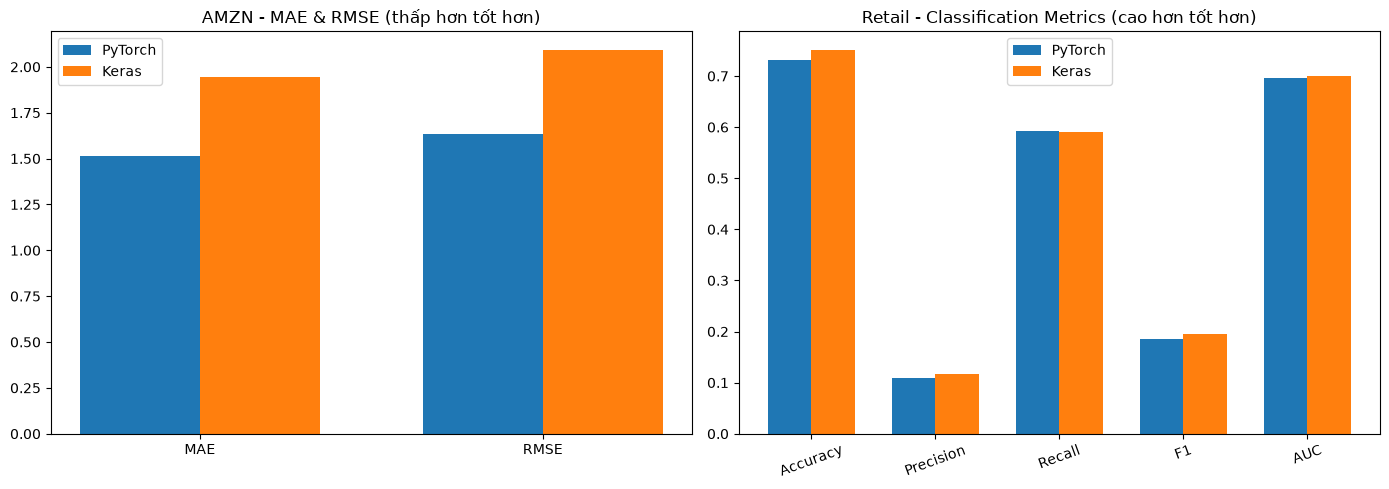

In [3]:
# ============================================================
# CELL 3: Bar chart so sánh
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AMZN
metrics = ['MAE', 'RMSE']
x = np.arange(len(metrics))
w = 0.35
axes[0].bar(x - w/2, [df_amzn['MAE'][0], df_amzn['RMSE'][0]], w, label='PyTorch')
axes[0].bar(x + w/2, [df_amzn['MAE'][1], df_amzn['RMSE'][1]], w, label='Keras')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_title('AMZN - MAE & RMSE (thấp hơn tốt hơn)')
axes[0].legend()

# Retail
metrics_r = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = np.arange(len(metrics_r))
axes[1].bar(x - w/2, [df_retail[m][0] for m in metrics_r], w, label='PyTorch')
axes[1].bar(x + w/2, [df_retail[m][1] for m in metrics_r], w, label='Keras')
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics_r, rotation=20)
axes[1].set_title('Retail - Classification Metrics (cao hơn tốt hơn)')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/04_compare_bar.png', dpi=200)
plt.show()

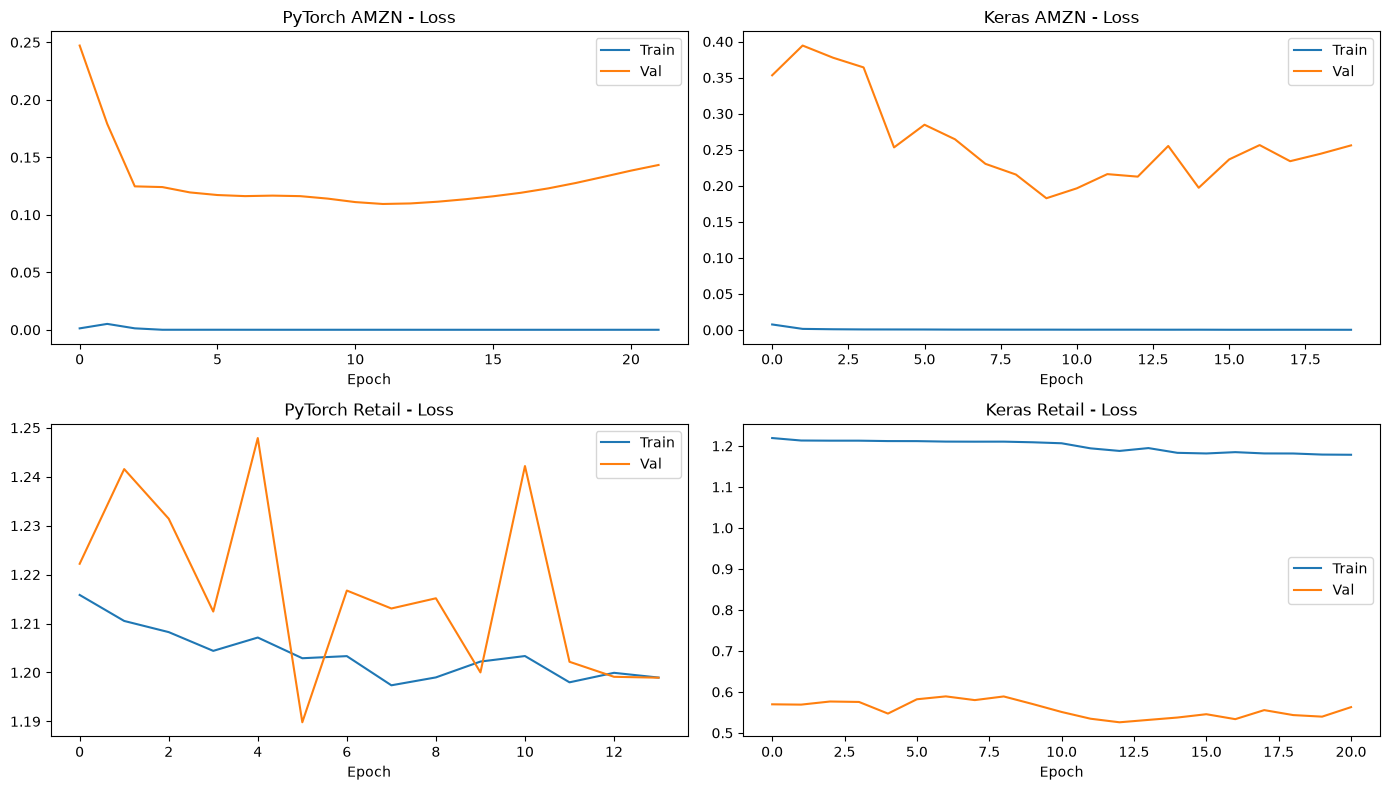

In [4]:
# ============================================================
# CELL 4: Learning curves
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(pt['hist_amzn']['train_loss'], label='Train')
axes[0,0].plot(pt['hist_amzn']['val_loss'], label='Val')
axes[0,0].set_title('PyTorch AMZN - Loss')
axes[0,0].set_xlabel('Epoch'); axes[0,0].legend()

axes[0,1].plot(kr['hist_amzn']['loss'], label='Train')
axes[0,1].plot(kr['hist_amzn']['val_loss'], label='Val')
axes[0,1].set_title('Keras AMZN - Loss')
axes[0,1].set_xlabel('Epoch'); axes[0,1].legend()

axes[1,0].plot(pt['hist_retail']['train_loss'], label='Train')
axes[1,0].plot(pt['hist_retail']['val_loss'], label='Val')
axes[1,0].set_title('PyTorch Retail - Loss')
axes[1,0].set_xlabel('Epoch'); axes[1,0].legend()

axes[1,1].plot(kr['hist_retail']['loss'], label='Train')
axes[1,1].plot(kr['hist_retail']['val_loss'], label='Val')
axes[1,1].set_title('Keras Retail - Loss')
axes[1,1].set_xlabel('Epoch'); axes[1,1].legend()

plt.tight_layout()
plt.savefig('outputs/04_learning_curves.png', dpi=200)
plt.show()

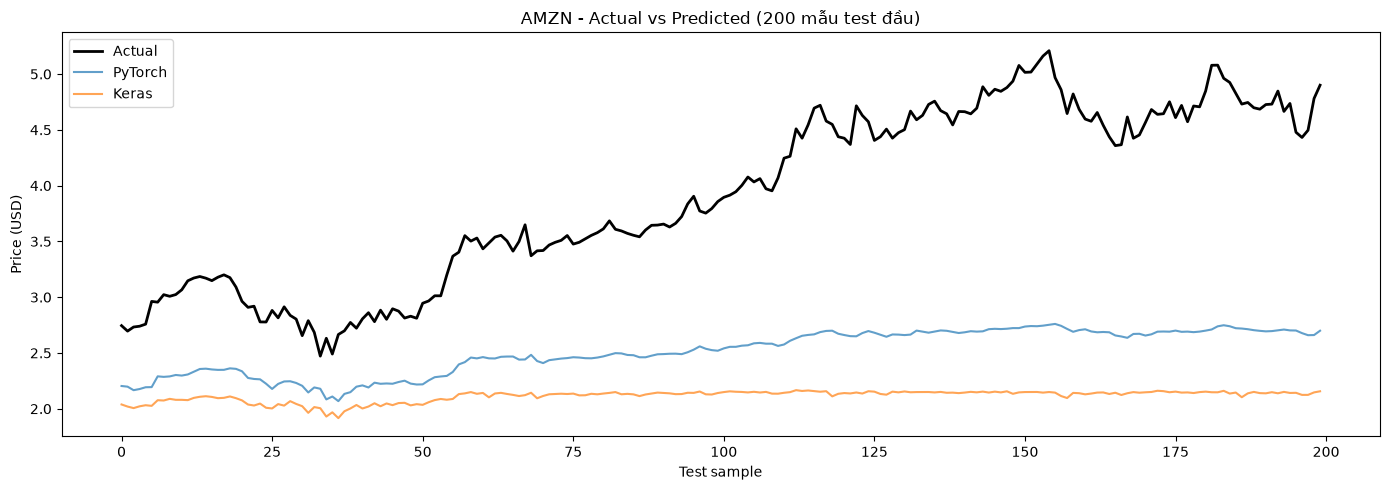

In [5]:
# ============================================================
# CELL 5: Actual vs Predicted (cả 2 framework trên cùng plot)
# ============================================================
plt.figure(figsize=(14, 5))
plt.plot(pt['y_amzn'][:200], label='Actual', color='black', linewidth=2)
plt.plot(pt['pred_amzn'][:200], label='PyTorch', alpha=0.7)
plt.plot(kr['pred_amzn'][:200], label='Keras', alpha=0.7)
plt.title('AMZN - Actual vs Predicted (200 mẫu test đầu)')
plt.xlabel('Test sample'); plt.ylabel('Price (USD)')
plt.legend(); plt.tight_layout()
plt.savefig('outputs/04_amzn_pred_compare.png', dpi=200)
plt.show()

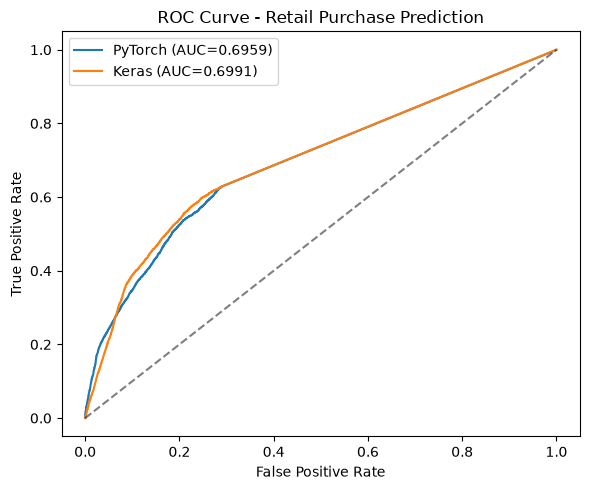

In [6]:
# ============================================================
# CELL 6: ROC Curve cho Retail
# ============================================================
from sklearn.metrics import roc_curve

fpr_pt, tpr_pt, _ = roc_curve(pt['y_retail'], pt['pred_retail'])
fpr_kr, tpr_kr, _ = roc_curve(kr['y_retail'], kr['pred_retail'])

plt.figure(figsize=(6, 5))
plt.plot(fpr_pt, tpr_pt, label=f"PyTorch (AUC={pt['retail']['auc']:.4f})")
plt.plot(fpr_kr, tpr_kr, label=f"Keras (AUC={kr['retail']['auc']:.4f})")
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Retail Purchase Prediction')
plt.legend(); plt.tight_layout()
plt.savefig('outputs/04_roc_retail.png', dpi=200)
plt.show()

In [9]:
# ============================================================
# CELL 7: Bảng tổng hợp cuối cho báo cáo
# ============================================================
final_summary = pd.concat([
    df_amzn.assign(Task='AMZN Regression'),
    df_retail.assign(Task='Retail Classification')
], ignore_index=True)
final_summary.to_csv('outputs/04_final_summary.csv', index=False)
print("\n=== FINAL SUMMARY ===")
print(final_summary.round(4).to_string(index=False))

print("\n=== END ===")


=== FINAL SUMMARY ===
Framework    MAE   RMSE      R2  MAPE (%)  Time (s)                  Task  Accuracy  Precision  Recall     F1    AUC
  PyTorch 1.5135 1.6367 -3.1182   35.5172   36.2216       AMZN Regression       NaN        NaN     NaN    NaN    NaN
    Keras 1.9420 2.0892 -5.7103   45.7078   27.7698       AMZN Regression       NaN        NaN     NaN    NaN    NaN
  PyTorch    NaN    NaN     NaN       NaN  534.2614 Retail Classification    0.7315     0.1095  0.5916 0.1848 0.6959
    Keras    NaN    NaN     NaN       NaN  856.2145 Retail Classification    0.7499     0.1170  0.5898 0.1953 0.6991

=== END ===
